In [2]:
import pandas as pd

df = pd.read_csv('dataset.csv')
df.head()

,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,279,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,476,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,594,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,271,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,256,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12


In [3]:
df.columns

Index(['segment', 'anomaly', 'train', 'channel', 'sampling', 'duration', 'len',
       'mean', 'var', 'std', 'kurtosis', 'skew', 'n_peaks', 'smooth10_n_peaks',
       'smooth20_n_peaks', 'diff_peaks', 'diff2_peaks', 'diff_var',
       'diff2_var', 'gaps_squared', 'len_weighted', 'var_div_duration',
       'var_div_len'],
      dtype='object')

# Seleção das Variáveis

Para a análise, foi escolhida a variável **n_peaks** como quantitativa discreta, pois representa uma contagem de eventos.

A variável **mean** foi escolhida como quantitativa contínua, pois representa valores numéricos com casas decimais.

In [4]:
var_discreta = 'n_peaks'

In [5]:
var_continua = 'mean'

# Tabelas de Frequência

Foram construídas tabelas de frequência para analisar a distribuição dos dados das variáveis selecionadas.

In [6]:
freq_discreta = df[var_discreta].value_counts().sort_index()

tabela_discreta = freq_discreta.reset_index()
tabela_discreta.columns = ['Valor', 'Frequência']

tabela_discreta

,Valor,Frequência
0,1,1654
1,2,313
2,3,78
3,4,21
4,5,13
5,6,11
6,7,4
7,8,2
8,9,3
9,10,3


In [7]:
freq_continua = pd.cut(df[var_continua], bins=5).value_counts().sort_index()

tabela_continua = freq_continua.reset_index()
tabela_continua.columns = ['Intervalo', 'Frequência']

tabela_continua

,Intervalo,Frequência
0,"(-0.00116, 0.224]",1648
1,"(0.224, 0.447]",349
2,"(0.447, 0.671]",67
3,"(0.671, 0.895]",30
4,"(0.895, 1.119]",29


# Gráficos Estatísticos

Os gráficos a seguir representam visualmente a distribuição das variáveis analisadas.

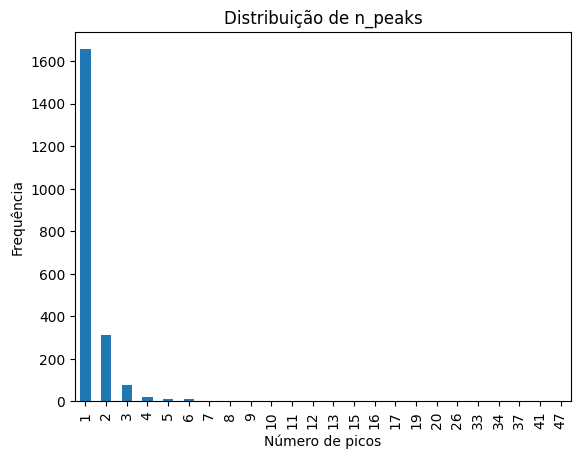

In [8]:
import matplotlib.pyplot as plt

df[var_discreta].value_counts().sort_index().plot(kind='bar')

plt.title('Distribuição de n_peaks')
plt.xlabel('Número de picos')
plt.ylabel('Frequência')

plt.show()

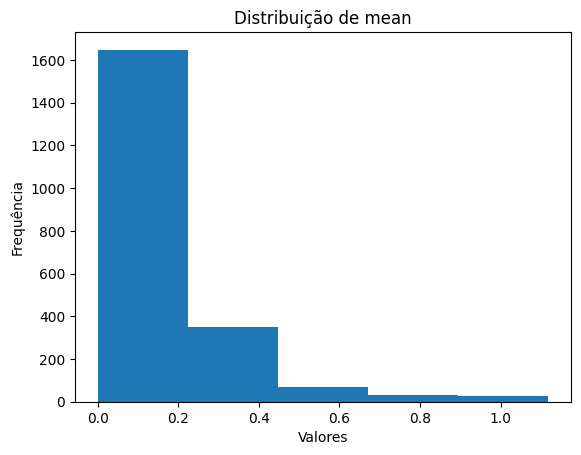

In [9]:
df[var_continua].plot(kind='hist', bins=5)

plt.title('Distribuição de mean')
plt.xlabel('Valores')
plt.ylabel('Frequência')

plt.show()

# Análise Estatística

A seguir, são apresentadas medidas estatísticas descritivas da variável escolhida.

In [10]:
media = df[var_continua].mean()
mediana = df[var_continua].median()
moda = df[var_continua].mode()[0]

maximo = df[var_continua].max()
minimo = df[var_continua].min()
amplitude = maximo - minimo

variancia = df[var_continua].var()
desvio = df[var_continua].std()

quartis = df[var_continua].quantile([0.25, 0.5, 0.75])

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

print("Máximo:", maximo)
print("Mínimo:", minimo)
print("Amplitude:", amplitude)

print("Variância:", variancia)
print("Desvio padrão:", desvio)

print("Quartis:")
print(quartis)

Média: 0.11096771797024252
Mediana: 4.515496298984771e-06
Moda: -3.8330304e-05
Máximo: 1.118631777777778
Mínimo: -3.8330304e-05
Amplitude: 1.1186701080817778
Variância: 0.03854016115388333
Desvio padrão: 0.19631648212486727
Quartis:
0.25   -7.239804e-07
0.50    4.515496e-06
0.75    2.051710e-01
Name: mean, dtype: float64
